<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Final_Lecture_Bike_Rental_Data_Mining_0521.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Final Lecture - Data Mining with Bike Rental Demand

**Date:** Thursday, 21 May 2026  
**Example dataset:** Bike Sharing / Bike Rental demand data (`hour.csv` and `day.csv`)  
**Main target:** predict hourly rental count, `cnt`  

This final lecture uses the bike rental dataset to demonstrate a complete data mining workflow:

1. define a prediction problem;
2. load and inspect data robustly;
3. avoid target leakage;
4. perform exploratory data analysis;
5. engineer features from time and weather fields;
6. split data into train, validation, and test periods;
7. compare linear regression, ridge regression, and a regularized neural network;
8. evaluate models using MAE, RMSE, standard test $R^2$, and baseline-relative improvement;
9. write a defensible final conclusion.

The structure follows the same project logic as the previous final-project example: EDA, train/validation/test split, model comparison, final model choice, architecture thinking, and limitations.


## 0. Why the Kaggle starter code failed

The automatically generated Kaggle starter code often hard-codes paths such as:

```python
../input/Bike-Sharing-Dataset/hour.csv
```

That can fail because the actual dataset folder may be lower-case, nested differently, or copied into a local folder. In this notebook we use a file finder instead of assuming one exact folder name.

Expected files:

```text
hour.csv
 day.csv
```

The notebook will search common locations, including the current folder, `data/`, `/mnt/data`, `/content`, `/kaggle/input`, and `../input`.


In [1]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFirst files in the current folder:")
for item in sorted(Path.cwd().glob("*"))[:30]:
    print(" ", item)


Current working directory:
/content

First files in the current folder:
  /content/.config
  /content/day.csv
  /content/hour.csv
  /content/sample_data


## 1. Import packages

This lecture uses standard Python data-mining tools:

- `pandas` for data tables;
- `numpy` for numeric operations;
- `matplotlib` for plots;
- `scikit-learn` for preprocessing, linear regression, ridge regression, neural networks, and metrics.

Install them if necessary:

```bash
pip install pandas numpy matplotlib scikit-learn
```


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({"font.size": 11})


## 2. Robust file finder

This cell fixes the path problem from the Kaggle bot example. It tries several common roots, then performs a limited recursive search inside Kaggle-style input folders.


In [3]:
CANDIDATE_DIRS = [
    Path("."),
    Path("data"),
    Path("/mnt/data"),
    Path("/content"),
    Path("/content/data"),
    Path("/content/drive/MyDrive/AKHU_labs"),
    Path("/kaggle/input"),
    Path("/kaggle/input/bike-sharing-dataset"),
    Path("/kaggle/input/Bike-Sharing-Dataset"),
    Path("../input"),
    Path("../input/bike-sharing-dataset"),
    Path("../input/Bike-Sharing-Dataset"),
]

RECURSIVE_ROOTS = [Path("/kaggle/input"), Path("../input"), Path("/mnt/data"), Path(".")]


def find_file(filename):
    print("Searching for:", filename)
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        if candidate.exists():
            print("Found:", candidate)
            return candidate

    for root in RECURSIVE_ROOTS:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                print("Found by recursive search:", matches[0])
                return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Put it beside this notebook, inside data/, "
        "or inside a Kaggle/Colab input folder."
    )

hour_path = find_file("hour.csv")
day_path = find_file("day.csv")


Searching for: hour.csv
Found: hour.csv
Searching for: day.csv
Found: day.csv


## 3. Load the bike rental data

We will use `hour.csv` for model training because it contains one row per hour. We will also load `day.csv` to show the daily version of the same demand process.


In [4]:
hour_df = pd.read_csv(hour_path)
day_df = pd.read_csv(day_path)

hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

hour_df = hour_df.sort_values(["dteday", "hr"]).reset_index(drop=True)
day_df = day_df.sort_values("dteday").reset_index(drop=True)

print("hour.csv shape:", hour_df.shape)
print("day.csv shape:", day_df.shape)

hour_df.head()


hour.csv shape: (17379, 17)
day.csv shape: (731, 16)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 4. Data dictionary and prediction target

For this lecture, the target is `cnt`, the total number of bike rentals in an hour.

Important leakage rule:

```text
casual + registered = cnt
```

Therefore, `casual` and `registered` are not valid predictors if the goal is to predict total demand before the hour occurs. They are components of the target, not independent features.


In [5]:
leakage_match_rate = ((hour_df["casual"] + hour_df["registered"]) == hour_df["cnt"]).mean()
print(f"Rows where casual + registered equals cnt: {leakage_match_rate:.3f}")

roles = []
for col in hour_df.columns:
    if col == "cnt":
        role = "target"
    elif col in ["casual", "registered"]:
        role = "leakage column - exclude from predictors"
    elif col in ["instant", "dteday"]:
        role = "identifier / date context"
    else:
        role = "candidate feature"
    roles.append(role)

data_dictionary = pd.DataFrame({
    "column": hour_df.columns,
    "role": roles,
    "example_value": [hour_df[col].iloc[0] for col in hour_df.columns],
    "dtype": [str(hour_df[col].dtype) for col in hour_df.columns],
})

data_dictionary


Rows where casual + registered equals cnt: 1.000


,column,role,example_value,dtype
0,instant,identifier / date context,1,int64
1,dteday,identifier / date context,2011-01-01 00:00:00,datetime64[ns]
2,season,candidate feature,1,int64
3,yr,candidate feature,0,int64
4,mnth,candidate feature,1,int64
5,hr,candidate feature,0,int64
6,holiday,candidate feature,0,int64
7,weekday,candidate feature,6,int64
8,workingday,candidate feature,0,int64
9,weathersit,candidate feature,1,int64


## 5. Basic inspection and missing values

Before modeling, inspect rows, columns, data types, missing values, and summary statistics. This is the minimum EDA step for a data mining project.


In [6]:
print("Rows and columns:", hour_df.shape)
print("\nDate range:", hour_df["dteday"].min().date(), "to", hour_df["dteday"].max().date())
print("\nMissing values by column:")
print(hour_df.isna().sum())

summary_cols = ["hr", "season", "yr", "holiday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]
hour_df[summary_cols].describe().T


Rows and columns: (17379, 17)

Date range: 2011-01-01 to 2012-12-31

Missing values by column:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507


## 6. Exploratory data analysis

EDA should answer practical questions before modeling:

- When are rentals highest?
- How does weather relate to demand?
- Does demand increase from 2011 to 2012?
- Are there seasonal, hourly, or weekly patterns?


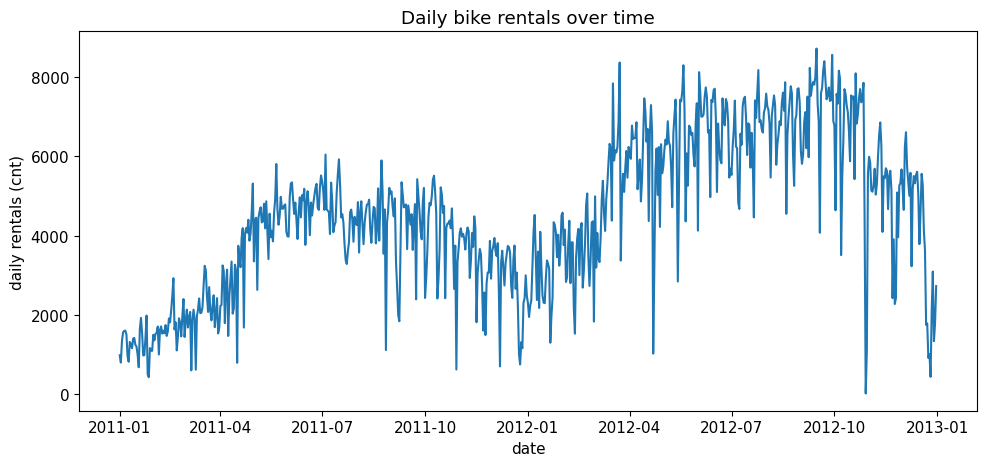

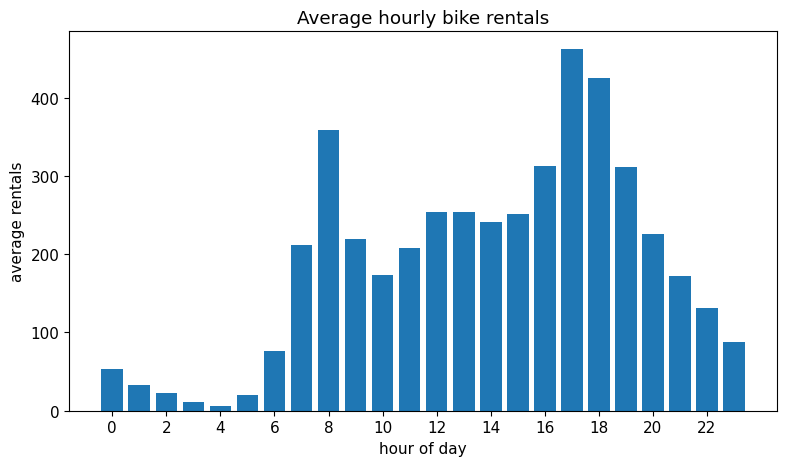

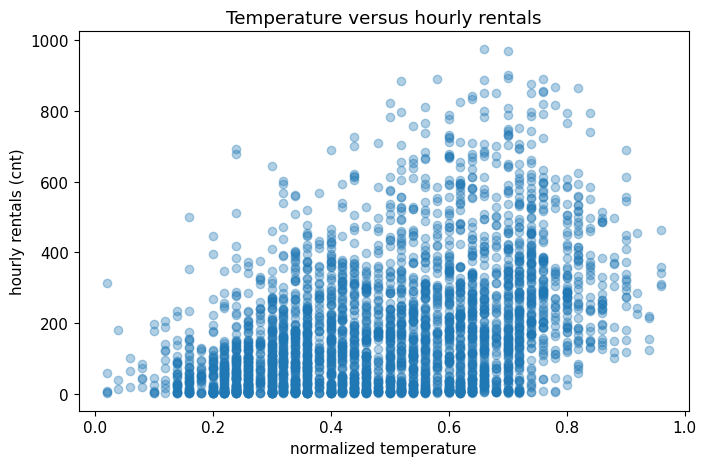

In [7]:
OUTPUT_DIR = Path("AKHU_CS_Final_Lecture_Bike_Rental_Data_Mining_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Daily trend from day.csv
plt.figure(figsize=(10, 4.8))
plt.plot(day_df["dteday"], day_df["cnt"])
plt.title("Daily bike rentals over time")
plt.xlabel("date")
plt.ylabel("daily rentals (cnt)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_daily_trend.png", dpi=160)
plt.show()

# 2. Average rentals by hour
hourly_pattern = hour_df.groupby("hr", as_index=False)["cnt"].mean()
plt.figure(figsize=(8, 4.8))
plt.bar(hourly_pattern["hr"], hourly_pattern["cnt"])
plt.title("Average hourly bike rentals")
plt.xlabel("hour of day")
plt.ylabel("average rentals")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_hourly_pattern.png", dpi=160)
plt.show()

# 3. Temperature versus count
sample_for_scatter = hour_df.sample(n=min(3500, len(hour_df)), random_state=42)
plt.figure(figsize=(7.2, 4.8))
plt.scatter(sample_for_scatter["temp"], sample_for_scatter["cnt"], alpha=0.35)
plt.title("Temperature versus hourly rentals")
plt.xlabel("normalized temperature")
plt.ylabel("hourly rentals (cnt)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_temp_vs_count.png", dpi=160)
plt.show()


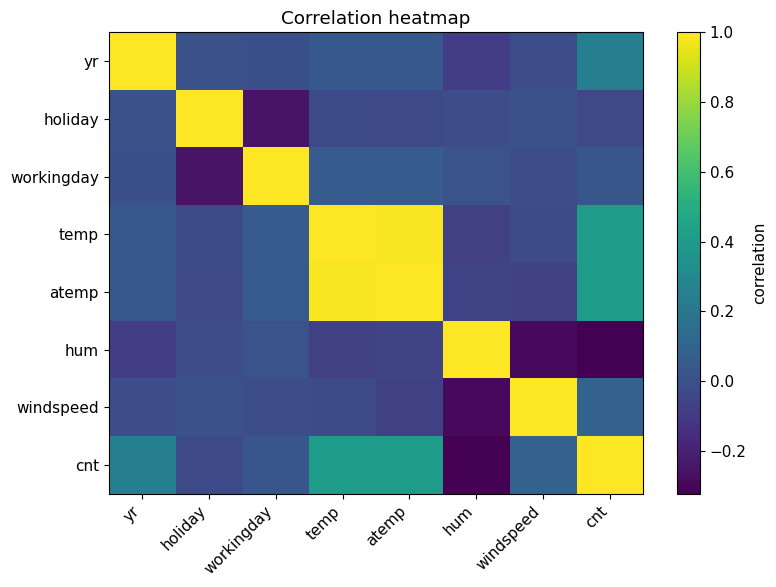

,cnt
cnt,1.000000
temp,0.404772
atemp,0.400929
yr,0.250495
windspeed,0.093234
workingday,0.030284
holiday,-0.030927
hum,-0.322911


In [8]:
# Correlation heatmap for numeric columns used in the lecture.
corr_cols = ["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed", "cnt"]
corr = hour_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_correlation_heatmap.png", dpi=160)
plt.show()

corr["cnt"].sort_values(ascending=False)


## 7. Feature engineering

Data mining is not only model fitting. It also includes choosing useful representations.

For the linear and ridge models, we will use:

- numeric weather/time flags: `yr`, `holiday`, `workingday`, `temp`, `atemp`, `hum`, `windspeed`;
- one-hot calendar variables: `season`, `mnth`, `hr`, `weekday`, `weathersit`.

For the neural network, we will use cyclic encodings for hour, month, and weekday. Cyclic encoding helps the model understand that hour `23` and hour `0` are close to each other.


In [9]:
def add_time_features(df):
    out = df.copy()
    cyclic_specs = [("hr", 24), ("mnth", 12), ("weekday", 7)]
    for col, period in cyclic_specs:
        out[f"{col}_sin"] = np.sin(2 * np.pi * out[col] / period)
        out[f"{col}_cos"] = np.cos(2 * np.pi * out[col] / period)

    out["is_peak_commute"] = out["hr"].isin([7, 8, 17, 18]).astype(int)
    out["is_night"] = out["hr"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    out["temp_hum_interaction"] = out["temp"] * out["hum"]
    return out

model_df = add_time_features(hour_df)

TARGET = "cnt"
LEAKAGE_COLUMNS = ["casual", "registered"]
ID_COLUMNS = ["instant", "dteday"]

numeric_basic = ["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed"]
categorical_calendar = ["season", "mnth", "hr", "weekday", "weathersit"]

numeric_mlp = numeric_basic + [
    "hr_sin", "hr_cos", "mnth_sin", "mnth_cos", "weekday_sin", "weekday_cos",
    "is_peak_commute", "is_night", "temp_hum_interaction",
]
categorical_mlp = ["season", "weathersit"]

print("Linear/ridge numeric features:", numeric_basic)
print("Linear/ridge one-hot calendar features:", categorical_calendar)
print("Neural-network numeric features:", numeric_mlp)
print("Excluded leakage columns:", LEAKAGE_COLUMNS)


Linear/ridge numeric features: ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']
Linear/ridge one-hot calendar features: ['season', 'mnth', 'hr', 'weekday', 'weathersit']
Neural-network numeric features: ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'is_peak_commute', 'is_night', 'temp_hum_interaction']
Excluded leakage columns: ['casual', 'registered']


## 8. Chronological train, validation, and test split

Because bike demand is time-dependent, this lecture uses a chronological split by date instead of a random split.

- Training period: first 70% of dates.
- Validation period: next 15% of dates.
- Test period: final 15% of dates.

Use the validation set for model choices and hyperparameters. Use the test set only for final evaluation.


In [10]:
unique_dates = np.array(sorted(model_df["dteday"].dt.date.unique()))
n_dates = len(unique_dates)
train_end = int(0.70 * n_dates)
val_end = int(0.85 * n_dates)

train_dates = set(unique_dates[:train_end])
val_dates = set(unique_dates[train_end:val_end])
test_dates = set(unique_dates[val_end:])

train_df = model_df[model_df["dteday"].dt.date.isin(train_dates)].copy()
val_df = model_df[model_df["dteday"].dt.date.isin(val_dates)].copy()
test_df = model_df[model_df["dteday"].dt.date.isin(test_dates)].copy()
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "start_date": [train_df["dteday"].min().date(), val_df["dteday"].min().date(), test_df["dteday"].min().date()],
    "end_date": [train_df["dteday"].max().date(), val_df["dteday"].max().date(), test_df["dteday"].max().date()],
})

split_summary


,split,rows,start_date,end_date
0,train,12139,2011-01-01,2012-05-25
1,validation,2640,2012-05-26,2012-09-12
2,test,2600,2012-09-13,2012-12-31


## 9. Evaluation metrics

We will report four metrics:

- **MAE:** mean absolute error. Lower is better.
- **RMSE:** root mean squared error. Lower is better and penalizes large errors.
- **Standard test $R^2$:** can be negative if the model is worse than the mean baseline on the test period.
- **Baseline-relative improvement:** nonnegative improvement over the mean baseline.

The baseline-relative score is:

$$
\text{baseline-relative } R^2 = \max\left(0, 1 - \frac{SSE_{model}}{SSE_{baseline}}\right).
$$

A value of `0.000` means the model does not beat the mean baseline. A value close to `1.000` means strong improvement over the baseline.


In [11]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def baseline_relative_r2(y_true, y_pred, baseline_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    baseline_pred = np.asarray(baseline_pred, dtype=float)
    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_baseline = np.sum((y_true - baseline_pred) ** 2)
    if np.isclose(sse_baseline, 0):
        return np.nan
    return float(max(0.0, 1.0 - sse_model / sse_baseline))


def evaluate_predictions(y_true, y_pred, baseline_pred):
    y_pred = np.maximum(0, np.asarray(y_pred, dtype=float))
    return {
        "test_MAE": float(mean_absolute_error(y_true, y_pred)),
        "test_RMSE": rmse(y_true, y_pred),
        "test_R2": float(r2_score(y_true, y_pred)),
        "baseline_relative_R2": baseline_relative_r2(y_true, y_pred, baseline_pred),
    }


## 10. Preprocessing pipeline

Linear regression, ridge regression, and neural networks need numeric arrays. We will:

- standardize numeric columns using `StandardScaler`;
- one-hot encode categorical columns using `OneHotEncoder`;
- combine preprocessing and model fitting inside a `Pipeline`.


In [12]:
def make_one_hot_encoder():
    """Compatibility helper for old and new scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(numeric_cols, categorical_cols):
    transformers = []
    if numeric_cols:
        transformers.append(("num", StandardScaler(), numeric_cols))
    if categorical_cols:
        transformers.append(("cat", make_one_hot_encoder(), categorical_cols))
    return ColumnTransformer(transformers=transformers, remainder="drop")


def make_pipeline_model(model, numeric_cols, categorical_cols):
    return Pipeline([
        ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
        ("model", model),
    ])


## 11. Model 1: mean baseline

A data mining project needs a baseline. For regression, the simplest baseline predicts the training mean for every test row.


In [13]:
baseline_value = float(trainval_df[TARGET].mean())
baseline_test_pred = np.full(len(test_df), baseline_value)

baseline_metrics = evaluate_predictions(test_df[TARGET], baseline_test_pred, baseline_test_pred)
print("Baseline prediction value:", round(baseline_value, 2))
baseline_metrics


Baseline prediction value: 181.47


{'test_MAE': 167.20344269675786,
 'test_RMSE': 220.8279511123888,
 'test_R2': -0.062203742943947704,
 'baseline_relative_R2': 0.0}

## 12. Model 2: linear regression

Linear regression assumes the prediction is a weighted sum of features:

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p.
$$

We will compare two linear versions:

1. numeric weather/time variables only;
2. numeric variables plus one-hot calendar variables.


In [14]:
linear_numeric = make_pipeline_model(
    LinearRegression(),
    numeric_cols=numeric_basic,
    categorical_cols=[],
)

linear_calendar = make_pipeline_model(
    LinearRegression(),
    numeric_cols=numeric_basic,
    categorical_cols=categorical_calendar,
)

# Validation check before final test evaluation.
linear_val_rows = []
for name, model, features in [
    ("Linear numeric", linear_numeric, numeric_basic),
    ("Linear one-hot calendar", linear_calendar, numeric_basic + categorical_calendar),
]:
    model.fit(train_df[features], train_df[TARGET])
    val_pred = np.maximum(0, model.predict(val_df[features]))
    linear_val_rows.append({
        "model": name,
        "validation_MAE": mean_absolute_error(val_df[TARGET], val_pred),
        "validation_RMSE": rmse(val_df[TARGET], val_pred),
    })

pd.DataFrame(linear_val_rows).sort_values("validation_RMSE")


,model,validation_MAE,validation_RMSE
1,Linear one-hot calendar,110.878840,141.951289
0,Linear numeric,163.807057,201.781558


## 13. Model 3: ridge regression with L2 regularization

Ridge regression is still a linear model, but it adds an L2 penalty:

$$
\min_{\beta}\left[\sum_i (y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2\right].
$$

The penalty discourages very large coefficients. This can help when features are correlated, such as `temp` and `atemp`.


In [15]:
print("Correlation between temp and atemp:")
print(hour_df[["temp", "atemp"]].corr())

ridge_alphas = [0.01, 0.1, 1, 10, 50, 100, 200]
ridge_validation_rows = []

for alpha in ridge_alphas:
    ridge_model = make_pipeline_model(
        Ridge(alpha=alpha),
        numeric_cols=numeric_basic,
        categorical_cols=categorical_calendar,
    )
    ridge_model.fit(train_df[numeric_basic + categorical_calendar], train_df[TARGET])
    val_pred = np.maximum(0, ridge_model.predict(val_df[numeric_basic + categorical_calendar]))
    ridge_validation_rows.append({
        "alpha": alpha,
        "validation_MAE": mean_absolute_error(val_df[TARGET], val_pred),
        "validation_RMSE": rmse(val_df[TARGET], val_pred),
    })

ridge_validation_df = pd.DataFrame(ridge_validation_rows).sort_values("validation_RMSE")
best_ridge_alpha = float(ridge_validation_df.iloc[0]["alpha"])
print("Best ridge alpha by validation RMSE:", best_ridge_alpha)
ridge_validation_df


Correlation between temp and atemp:
           temp     atemp
temp   1.000000  0.987672
atemp  0.987672  1.000000
Best ridge alpha by validation RMSE: 0.01


,alpha,validation_MAE,validation_RMSE
0,0.01,110.879624,141.952269
1,0.10,110.886676,141.961085
2,1.00,110.957237,142.049010
3,10.00,111.660797,142.914300
4,50.00,114.632630,146.519961
5,100.00,117.927125,150.504324
6,200.00,123.382937,157.020599


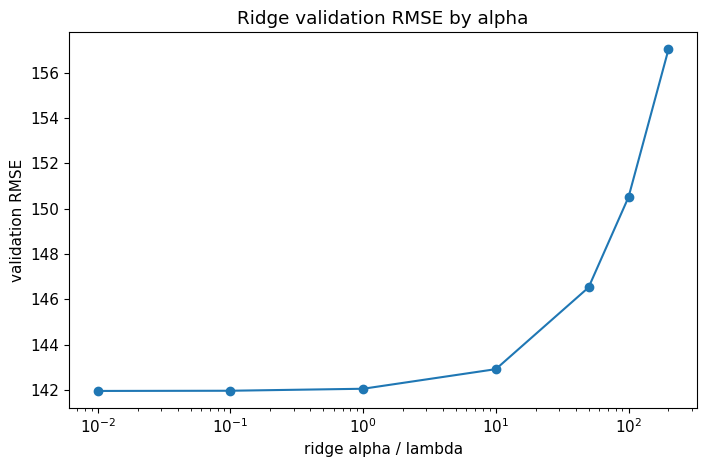

In [16]:
plt.figure(figsize=(7.2, 4.8))
plt.plot(ridge_validation_df.sort_values("alpha")["alpha"], ridge_validation_df.sort_values("alpha")["validation_RMSE"], marker="o")
plt.xscale("log")
plt.title("Ridge validation RMSE by alpha")
plt.xlabel("ridge alpha / lambda")
plt.ylabel("validation RMSE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_ridge_alpha_validation.png", dpi=160)
plt.show()


## 14. Model 4: neural network with regularization

The neural network uses a multilayer perceptron regressor. It is more flexible than linear regression because it can learn nonlinear interactions.

Regularization choices in this notebook:

- standardized numeric inputs;
- cyclic time features for hour, month, and weekday;
- L2 weight penalty through `alpha=0.01`;
- early stopping using an internal validation split;
- moderate architecture: two hidden layers, `(32, 16)`, instead of a very large network.

A neural network is not automatically better. It must be compared on the same test set as the simpler models.


In [17]:
mlp_regularized = make_pipeline_model(
    MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.01,                 # L2 weight penalty
        early_stopping=True,        # stop when internal validation score stops improving
        validation_fraction=0.15,
        max_iter=200,
        random_state=42,
        learning_rate_init=0.005,
        n_iter_no_change=10,
        batch_size=256,
    ),
    numeric_cols=numeric_mlp,
    categorical_cols=categorical_mlp,
)

print(mlp_regularized)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['yr', 'holiday',
                                                   'workingday', 'temp',
                                                   'atemp', 'hum', 'windspeed',
                                                   'hr_sin', 'hr_cos',
                                                   'mnth_sin', 'mnth_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'is_peak_commute',
                                                   'is_night',
                                                   'temp_hum_interaction']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
    

## 15. Final test-set model comparison

After validation choices are complete, we refit candidate models on `train + validation` and evaluate once on the test set.


In [18]:
model_specs = [
    {
        "name": "Mean baseline",
        "model": None,
        "numeric": [],
        "categorical": [],
    },
    {
        "name": "Linear regression: weather/time numeric",
        "model": make_pipeline_model(LinearRegression(), numeric_basic, []),
        "numeric": numeric_basic,
        "categorical": [],
    },
    {
        "name": "Linear regression: one-hot calendar",
        "model": make_pipeline_model(LinearRegression(), numeric_basic, categorical_calendar),
        "numeric": numeric_basic,
        "categorical": categorical_calendar,
    },
    {
        "name": f"Ridge regression: one-hot calendar, alpha={best_ridge_alpha:g}",
        "model": make_pipeline_model(Ridge(alpha=best_ridge_alpha), numeric_basic, categorical_calendar),
        "numeric": numeric_basic,
        "categorical": categorical_calendar,
    },
    {
        "name": "Neural network: L2 alpha=0.01 + early stopping",
        "model": mlp_regularized,
        "numeric": numeric_mlp,
        "categorical": categorical_mlp,
    },
]

results = []
predictions = {}

y_test = test_df[TARGET]
baseline_final_value = float(trainval_df[TARGET].mean())
baseline_final_pred = np.full(len(test_df), baseline_final_value)

for spec in model_specs:
    name = spec["name"]
    model = spec["model"]
    numeric_cols = spec["numeric"]
    categorical_cols = spec["categorical"]
    features = numeric_cols + categorical_cols

    if model is None:
        pred = baseline_final_pred
    else:
        model.fit(trainval_df[features], trainval_df[TARGET])
        pred = model.predict(test_df[features])

    pred = np.maximum(0, np.asarray(pred, dtype=float))
    predictions[name] = pred

    row = {"model": name}
    row.update(evaluate_predictions(y_test, pred, baseline_final_pred))
    if name.startswith("Neural network"):
        row["extra_note"] = f"MLP iterations: {model.named_steps['model'].n_iter_}"
    else:
        row["extra_note"] = ""
    results.append(row)

results_df = pd.DataFrame(results).sort_values("test_RMSE").reset_index(drop=True)
results_df


,model,test_MAE,test_RMSE,test_R2,baseline_relative_R2,extra_note
0,Neural network: L2 alpha=0.01 + early stopping,54.867285,75.980859,0.874250,0.881614,MLP iterations: 132
1,Linear regression: one-hot calendar,94.371442,129.040128,0.637299,0.658539,
2,"Ridge regression: one-hot calendar, alpha=0.01",94.371930,129.040530,0.637296,0.658537,
3,Linear regression: weather/time numeric,138.487246,193.440294,0.184932,0.232664,
4,Mean baseline,167.203443,220.827951,-0.062204,0.000000,


Saved model-comparison table to: AKHU_CS_Final_Lecture_Bike_Rental_Data_Mining_outputs/bike_model_comparison_test_set.csv


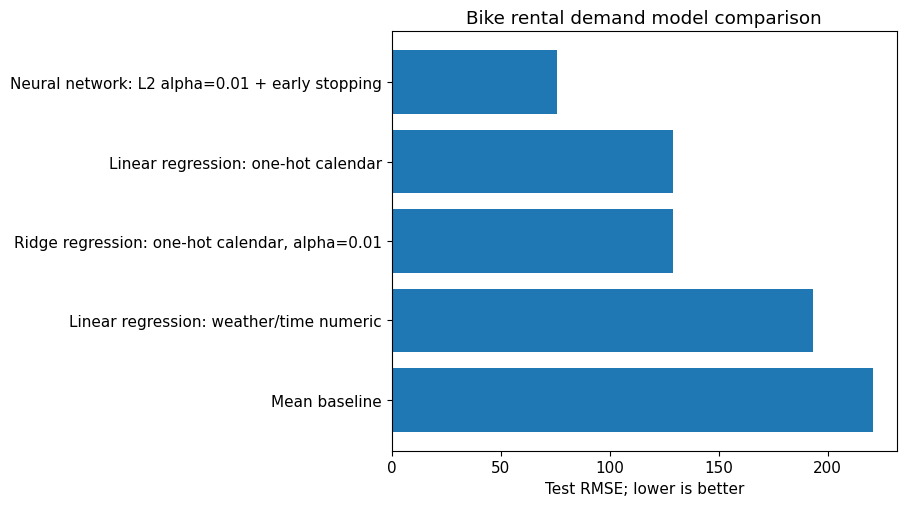

In [19]:
results_path = OUTPUT_DIR / "bike_model_comparison_test_set.csv"
results_df.to_csv(results_path, index=False)
print("Saved model-comparison table to:", results_path)

plot_df = results_df.sort_values("test_RMSE", ascending=False)
plt.figure(figsize=(9.2, 5.2))
plt.barh(plot_df["model"], plot_df["test_RMSE"])
plt.xlabel("Test RMSE; lower is better")
plt.title("Bike rental demand model comparison")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_model_comparison_rmse.png", dpi=160)
plt.show()


## 16. Actual versus predicted plot for the winning model

A model-comparison table is useful, but a scatter plot helps students see whether predictions are systematically too high or too low.


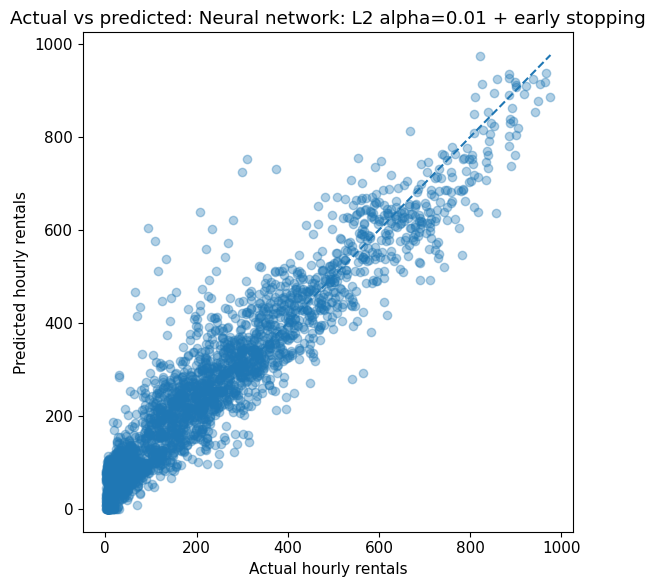

Best model by test RMSE: Neural network: L2 alpha=0.01 + early stopping


In [20]:
best_model_name = results_df.iloc[0]["model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.35)
min_value = min(float(y_test.min()), float(best_pred.min()))
max_value = max(float(y_test.max()), float(best_pred.max()))
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual hourly rentals")
plt.ylabel("Predicted hourly rentals")
plt.title(f"Actual vs predicted: {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_actual_vs_predicted_best_model.png", dpi=160)
plt.show()

print("Best model by test RMSE:", best_model_name)


## 17. Coefficient comparison: linear regression versus ridge

Ridge regression may not always beat ordinary linear regression on test RMSE. Its main purpose is to control coefficient size and reduce instability when predictors are correlated.

The comparison below uses a stronger ridge value (`alpha=10`) only for teaching coefficient shrinkage. The final test comparison above uses the validation-selected ridge alpha.


In [21]:
linear_for_coef = make_pipeline_model(LinearRegression(), numeric_basic, [])
ridge_for_coef = make_pipeline_model(Ridge(alpha=10), numeric_basic, [])

linear_for_coef.fit(trainval_df[numeric_basic], trainval_df[TARGET])
ridge_for_coef.fit(trainval_df[numeric_basic], trainval_df[TARGET])

coef_df = pd.DataFrame({
    "feature": numeric_basic,
    "linear_standardized_coef": linear_for_coef.named_steps["model"].coef_,
    "ridge_alpha10_standardized_coef": ridge_for_coef.named_steps["model"].coef_,
})
coef_df["absolute_shrinkage"] = (
    coef_df["linear_standardized_coef"].abs()
    - coef_df["ridge_alpha10_standardized_coef"].abs()
)
coef_df


,feature,linear_standardized_coef,ridge_alpha10_standardized_coef,absolute_shrinkage
0,yr,30.694792,30.680108,0.014684
1,holiday,-3.721197,-3.717992,0.003205
2,workingday,0.642114,0.643195,-0.001081
3,temp,36.060076,36.005224,0.054852
4,atemp,33.574236,33.609215,-0.034979
5,hum,-47.551830,-47.521947,0.029883
6,windspeed,7.019892,7.024338,-0.004446


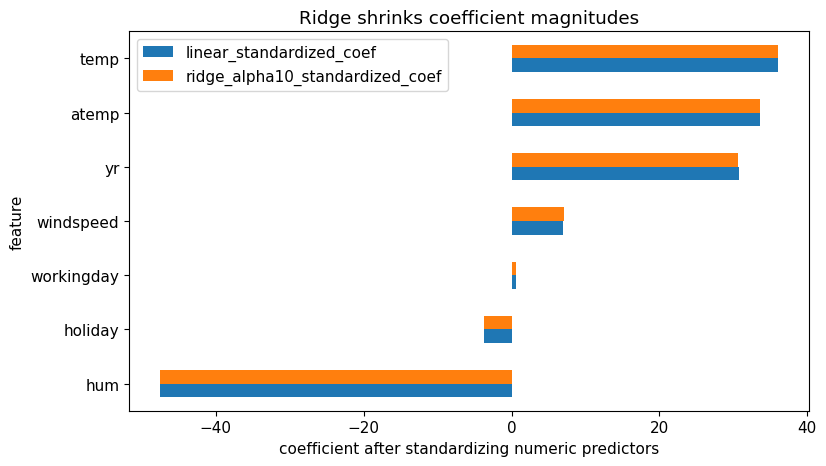

In [22]:
coef_plot_df = coef_df.set_index("feature")[["linear_standardized_coef", "ridge_alpha10_standardized_coef"]]
coef_plot_df = coef_plot_df.sort_values("linear_standardized_coef")
ax = coef_plot_df.plot(kind="barh", figsize=(8.4, 4.8))
ax.set_xlabel("coefficient after standardizing numeric predictors")
ax.set_title("Ridge shrinks coefficient magnitudes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bike_ridge_coefficient_comparison.png", dpi=160)
plt.show()


## 18. Interpretation template

Use this structure when writing the final project explanation.


In [23]:
best_row = results_df.iloc[0]
interpretation = f"""
Final model decision
--------------------
The best model on the chronological test period is: {best_row['model']}.
Its test RMSE is {best_row['test_RMSE']:.3f}, and its test MAE is {best_row['test_MAE']:.3f}.
Its standard test R-squared is {best_row['test_R2']:.3f}.
Its nonnegative baseline-relative improvement score is {best_row['baseline_relative_R2']:.3f}.

Teaching interpretation
-----------------------
1. The mean baseline is necessary because it tells us how hard the problem is.
2. Linear regression improves when calendar variables such as hour and weekday are encoded.
3. Ridge regression demonstrates L2 regularization. In this split, validation chose weak regularization, so ridge behaves almost like ordinary linear regression.
4. The regularized neural network performs best in this run because it can learn nonlinear interactions among time, weather, and demand.
5. The final model should still be described with limitations: this is historical data from one system, demand changes over time, and external events are not included.
"""
print(interpretation)



Final model decision
--------------------
The best model on the chronological test period is: Neural network: L2 alpha=0.01 + early stopping.
Its test RMSE is 75.981, and its test MAE is 54.867.
Its standard test R-squared is 0.874.
Its nonnegative baseline-relative improvement score is 0.882.

Teaching interpretation
-----------------------
1. The mean baseline is necessary because it tells us how hard the problem is.
2. Linear regression improves when calendar variables such as hour and weekday are encoded.
3. Ridge regression demonstrates L2 regularization. In this split, validation chose weak regularization, so ridge behaves almost like ordinary linear regression.
4. The regularized neural network performs best in this run because it can learn nonlinear interactions among time, weather, and demand.
5. The final model should still be described with limitations: this is historical data from one system, demand changes over time, and external events are not included.



## 19. Generate a short report starter

This cell writes a Markdown report starter that can be edited into a final submission.


In [24]:
report_text = f"""# Bike Rental Demand Data Mining Report Starter

## 1. Problem statement
Predict hourly bike rental demand (`cnt`) using calendar and weather variables.

## 2. Dataset
- Hourly rows: {len(hour_df)}
- Daily rows: {len(day_df)}
- Date range: {hour_df['dteday'].min().date()} to {hour_df['dteday'].max().date()}

## 3. Target and leakage
- Target: `cnt`
- Excluded leakage columns: `casual`, `registered`
- Reason: `casual + registered = cnt`

## 4. Split strategy
| Split | Rows | Start | End |
|---|---:|---|---|
| Train | {len(train_df)} | {train_df['dteday'].min().date()} | {train_df['dteday'].max().date()} |
| Validation | {len(val_df)} | {val_df['dteday'].min().date()} | {val_df['dteday'].max().date()} |
| Test | {len(test_df)} | {test_df['dteday'].min().date()} | {test_df['dteday'].max().date()} |

## 5. Model comparison
{results_df.to_markdown(index=False)}

## 6. Final decision
Best model by test RMSE: **{best_model_name}**.

## 7. Limitations
- The data covers only one bike-sharing system and one historical period.
- Weather fields are simplified and normalized.
- External events, station capacity, and pricing information are not included.
- A chronological test split is harder than a random split but more realistic for forecasting.

## 8. Next steps
- Add richer time features and public-event data.
- Compare tree-based models.
- Monitor error by hour, season, and weather condition.
- Build a simple API or dashboard for demand prediction.
"""

report_path = OUTPUT_DIR / "bike_rental_report_starter.md"
report_path.write_text(report_text, encoding="utf-8")
print("Saved report starter to:", report_path)


Saved report starter to: AKHU_CS_Final_Lecture_Bike_Rental_Data_Mining_outputs/bike_rental_report_starter.md


## 20. Final lecture checklist

Before submitting a final data mining project, verify that the notebook answers these questions:

- [ ] What is the prediction target?
- [ ] Which columns are excluded because of leakage?
- [ ] What did EDA show?
- [ ] What split strategy was used, and why?
- [ ] What baseline was used?
- [ ] Which models were compared?
- [ ] Which metric selected the final model?
- [ ] Did regularization help, hurt, or behave similarly?
- [ ] What are the limitations?
- [ ] What would be improved in the next version?
